In [2]:
import numpy as np
from quspin.basis import boson_basis_general
from quspin.operators import hamiltonian


# 1] 2D lattice of spin-s

In [16]:
Lx, Ly = 4, 4  # linear dimension of spin 1/2 2d lattice
U, mu = 4, 1

N_2d = Lx * Ly  # number of sites for spin 1/2
s = np.arange(N_2d)  # sites [0,1,2,....]
x = s % Lx  # x positions for sites
y = s // Lx  # y positions for sites
T_x = (x + 1) % Lx + Lx * y  # translation along x-direction
T_y = x + Lx * ((y + 1) % Ly)  # translation along y-direction
# P_x = x + Lx * (Ly - y - 1)  # reflection about x-axis
# P_y = (Lx - x - 1) + Lx * y  # reflection about y-axis
TT_x = (x + 2) % Lx + Lx * y  # translation along x-direction
TT_y = x + Lx * ((y + 2) % Ly)  # translation along y-direction
# Z = -(s + 1)  # spin inversion
print(T_x)
print(T_y)

[ 1  2  3  0  5  6  7  4  9 10 11  8 13 14 15 12]
[ 4  5  6  7  8  9 10 11 12 13 14 15  0  1  2  3]


In [ ]:
###### setting up bases ######
Nb = N_2d//2
basis_2d = boson_basis_general(
    N_2d,
    sps=3,
    kxblock=(TT_x, 1),
    kyblock=(TT_y, 1),
    # Nb=Nb
)
print("Size of 2D H-space: {Ns:d}".format(Ns=basis_2d.Ns))

In [ ]:
# setting up hamiltonians

# 2d (nx)
hn_2d = [[mu, i] for i in range(N_2d)]
Hn_2d = hamiltonian([["n", hn_2d]], [], basis=basis_2d, dtype=np.float64)

# 2d (nx ny)
Jnn_2d = [[U, i, T_x[i]] for i in range(N_2d)] + [[U, i, T_y[i]] for i in range(N_2d)]
Hnn_2d = hamiltonian([["nn", Jnn_2d]], [], basis=basis_2d, dtype=np.float64)

Htot = Hn_2d + Hnn_2d

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!


# 2] Compute expectation values of occupation number

In [ ]:
from quspin.operators import exp_op
import scipy
# construct gibbs state

dtype_real = np.float64
list_T_over_mu = np.logspace(-1, 4, num=9)
# list_T_over_mu = [10]

all_avg_particle_number = []
for T_over_mu in list_T_over_mu:
    exp_Htot_diag = np.exp(- Htot.diagonal()/(T_over_mu * mu))
    traceless_exp_Htot_diag = exp_Htot_diag / exp_Htot_diag.sum()
    # print(traceless_exp_Htot_diag)
    all_particle_number = np.zeros((len(traceless_exp_Htot_diag), N_2d))
    for index, proba in enumerate(traceless_exp_Htot_diag):
        str_state = basis_2d.int_to_state(basis_2d.states[index], bracket_notation=False)
        # str_state = basis_2d.int_to_state(basis_2d.Ns - basis_2d.states[index] - 1, bracket_notation=False)
        # print(str_state, proba)
        all_particle_number[index, :] = np.array(list(map(int,str_state))) * proba

    avg_particle_number = np.sum(all_particle_number, axis=0)
    all_avg_particle_number.append(avg_particle_number)

print(np.round(all_avg_particle_number, decimals=1))

[[1.  0.  0.  0.  0.  0.  0.  0.  0. ]
 [1.1 0.  0.  0.  0.1 0.1 0.  0.  0. ]
 [1.9 0.  0.  0.  0.4 0.4 0.  0.3 0.2]
 [2.3 0.2 0.1 0.2 0.5 0.6 0.1 0.5 0.4]
 [2.7 0.9 0.5 0.6 0.8 0.8 0.6 0.8 0.8]
 [2.9 1.6 0.9 1.1 1.1 1.1 1.  1.  1.1]
 [2.9 1.9 1.1 1.3 1.2 1.2 1.2 1.2 1.2]
 [2.9 2.  1.1 1.3 1.2 1.2 1.2 1.2 1.2]
 [2.9 2.  1.1 1.3 1.2 1.2 1.2 1.2 1.2]]


In [ ]:
# for index, proba in enumerate(traceless_exp_Htot_diag):
    # str_state = basis_2d.int_to_state(sbase**N_2d - basis_2d.states[index]-2, bracket_notation=False)
    # print(str_state, basis_2d.states[index])

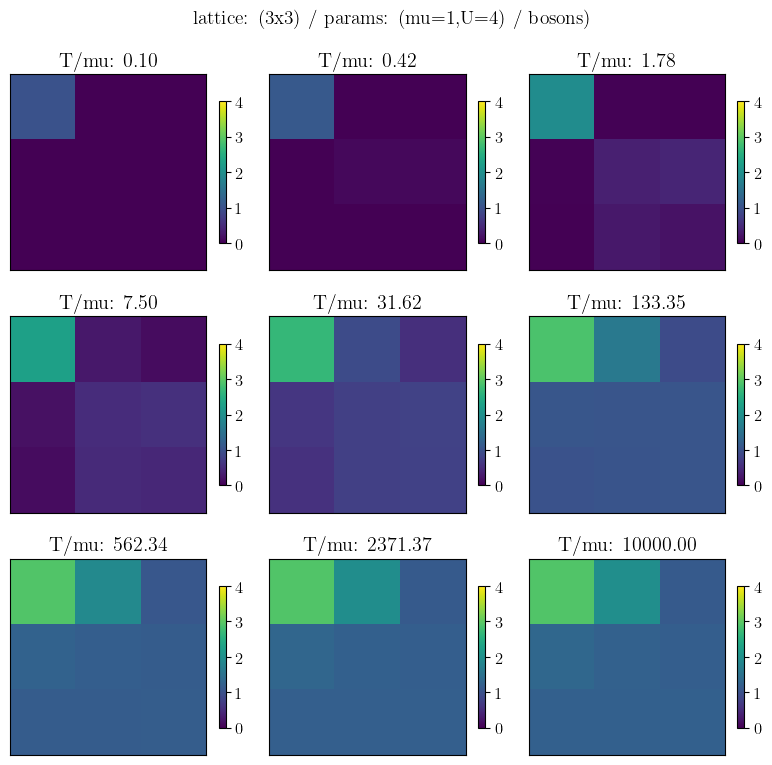

In [ ]:
import matplotlib.pyplot as plt
# print(all_avg_particle_number)

ncols = 3
fig, ax = plt.subplots(ncols = ncols, nrows=len(list_T_over_mu)//ncols, figsize = (8, 8))
for ii, T_over_mu, avg_particle_number in zip(range(len(list_T_over_mu)), list_T_over_mu, all_avg_particle_number):
    img = ax[ii//ncols][ii%ncols].imshow(np.round(avg_particle_number, decimals=2).reshape((Lx, Ly)), vmin=0, vmax = Nb)
    ax[ii//ncols][ii%ncols].set_title(f"T/mu: {T_over_mu:.02f}")
    ax[ii//ncols][ii%ncols].set_xticks([])
    ax[ii//ncols][ii%ncols].set_yticks([])
    fig.colorbar(img, ax=ax[ii//ncols][ii%ncols], shrink=0.6)
# plt.plot(list_beta, all_avg_particle_number)

plt.suptitle(f"lattice: ({Lx}x{Ly}) / params: (mu={mu},U={U}) / bosons)", fontsize=14)
fig.tight_layout()
# plt.savefig(f"lattice{Lx}x{Ly}.pdf")